In [2]:
import pandas as pd

df = pd.read_csv("../data/raw/train.csv")
df.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440832 entries, 0 to 440831
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         440832 non-null  float64
 1   Age                440832 non-null  float64
 2   Gender             440832 non-null  object 
 3   Tenure             440832 non-null  float64
 4   Usage Frequency    440832 non-null  float64
 5   Support Calls      440832 non-null  float64
 6   Payment Delay      440832 non-null  float64
 7   Subscription Type  440832 non-null  object 
 8   Contract Length    440832 non-null  object 
 9   Total Spend        440832 non-null  float64
 10  Last Interaction   440832 non-null  float64
 11  Churn              440832 non-null  float64
dtypes: float64(9), object(3)
memory usage: 40.4+ MB


In [4]:
df.describe()

,CustomerID,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
count,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000
mean,225398.667955,39.373153,31.256336,15.807494,3.604437,12.965722,631.616223,14.480868,0.567107
std,129531.918550,12.442369,17.255727,8.586242,3.070218,8.258063,240.803001,8.596208,0.495477
min,2.000000,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000,1.000000,0.000000
25%,113621.750000,29.000000,16.000000,9.000000,1.000000,6.000000,480.000000,7.000000,0.000000
50%,226125.500000,39.000000,32.000000,16.000000,3.000000,12.000000,661.000000,14.000000,1.000000
75%,337739.250000,48.000000,46.000000,23.000000,6.000000,19.000000,830.000000,22.000000,1.000000
max,449999.000000,65.000000,60.000000,30.000000,10.000000,30.000000,1000.000000,30.000000,1.000000


In [5]:
print(f"Total null value: {df.isnull().sum().sum()}")

Total null value: 0


In [6]:
print("Total missing value for each columns:")
df.isnull().sum()

Total missing value for each columns:


CustomerID           0
Age                  0
Gender               0
Tenure               0
Usage Frequency      0
Support Calls        0
Payment Delay        0
Subscription Type    0
Contract Length      0
Total Spend          0
Last Interaction     0
Churn                0
dtype: int64

In [7]:
df = df.drop(["CustomerID"], axis=1)
df.head()

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0


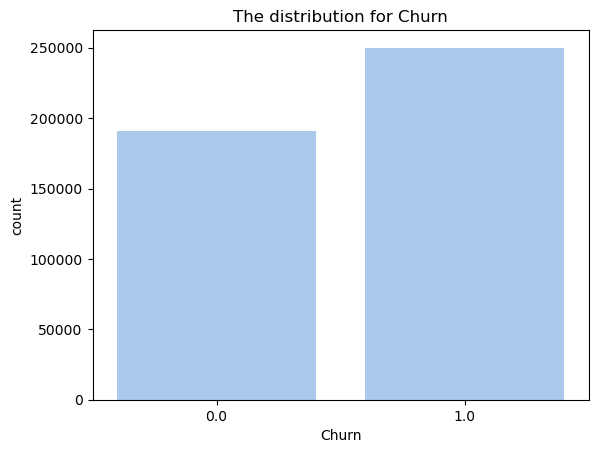

In [8]:
import seaborn as sns
from matplotlib import pyplot as plt

sns.set_palette("pastel")

sns.countplot(data=df, x="Churn")
plt.title("The distribution for Churn")
plt.show()

In [9]:
print("Churn count:")
df["Churn"].value_counts()

Churn count:


Churn
1.0    249999
0.0    190833
Name: count, dtype: int64

In [ ]:
churn_ratios = df["Churn"].value_counts(normalize=True)

print(f"\nChurn (1.0): {churn_ratios[1.0] * 100:.2f}%")
print(f"No Churn (0.0): {churn_ratios[0.0] * 100:.2f}%")


Churn (1.0): 56.71%
No Churn (0.0): 43.29%


In [ ]:
import numpy as np

numerical_features = [
    col for col in df.columns if df[col].dtype == np.float64 and col != "Churn"
]
numerical_features

['Age',
 'Tenure',
 'Usage Frequency',
 'Support Calls',
 'Payment Delay',
 'Total Spend',
 'Last Interaction']

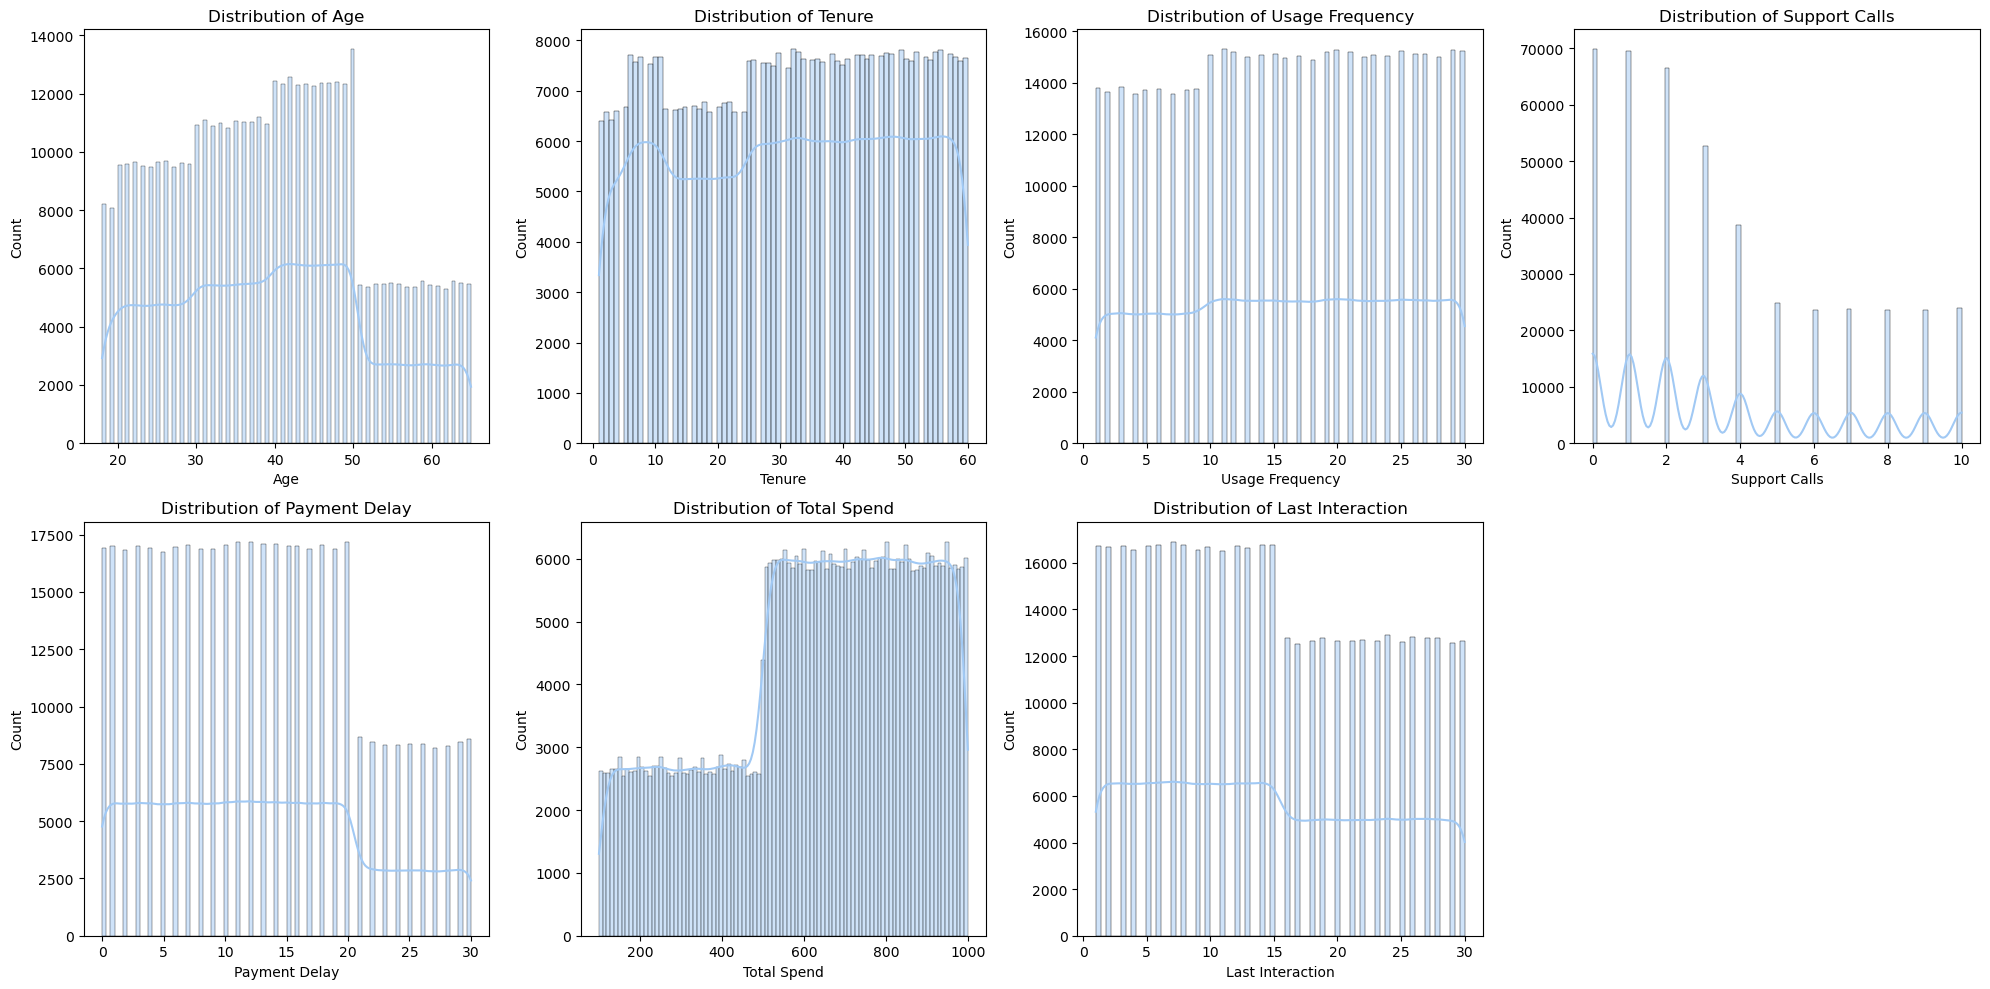

In [ ]:
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(20, 10))
axes_list = axes.flatten()

for feature, ax in zip(numerical_features, axes_list):
    sns.histplot(data=df, x=feature, kde=True, ax=ax)
    ax.set_title(f"Distribution of {feature}")

axes_list[7].axis("off")
plt.tight_layout()
plt.show()

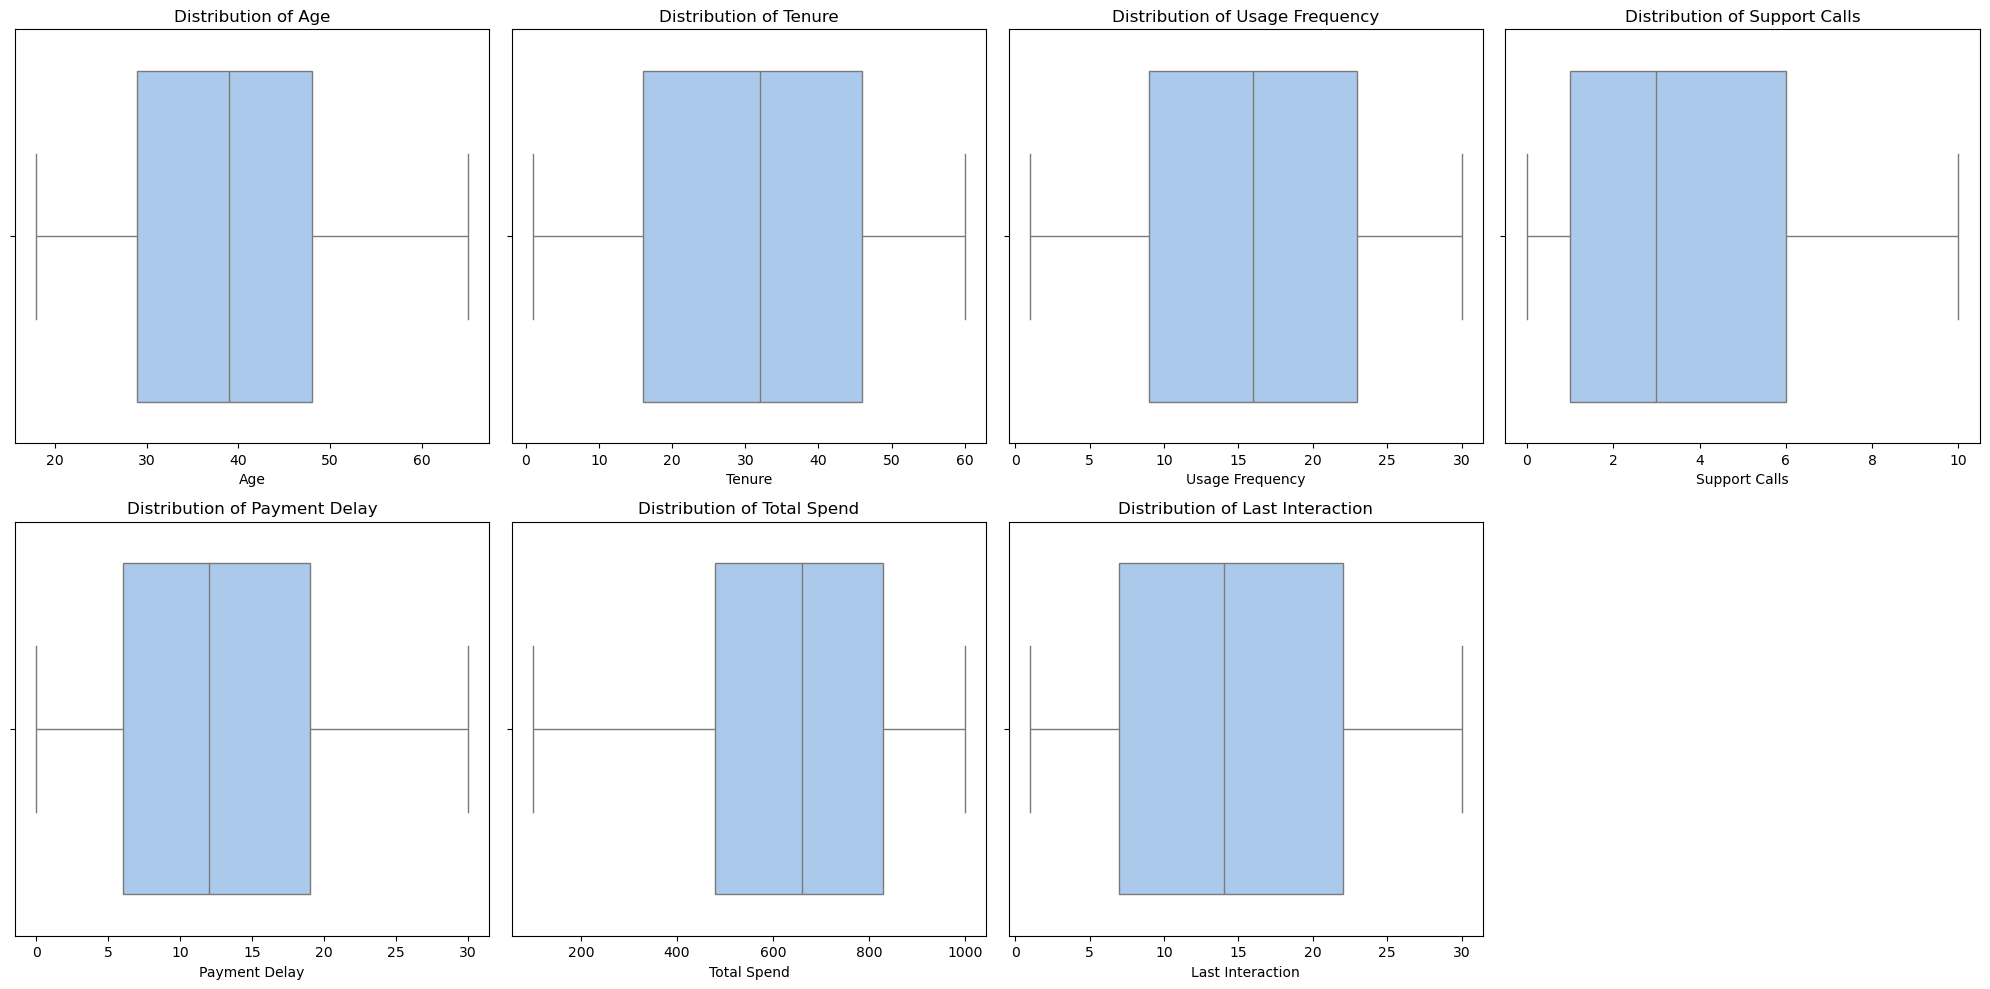

In [ ]:
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(20, 10))
axes_list = axes.flatten()

for feature, ax in zip(numerical_features, axes_list):
    sns.boxplot(data=df, x=feature, ax=ax)
    ax.set_title(f"Distribution of {feature}")

axes_list[7].axis("off")
plt.tight_layout()
plt.show()

In [ ]:
categorical_features = [col for col in df.columns if df[col].dtype == object]
categorical_features

['Gender', 'Subscription Type', 'Contract Length']

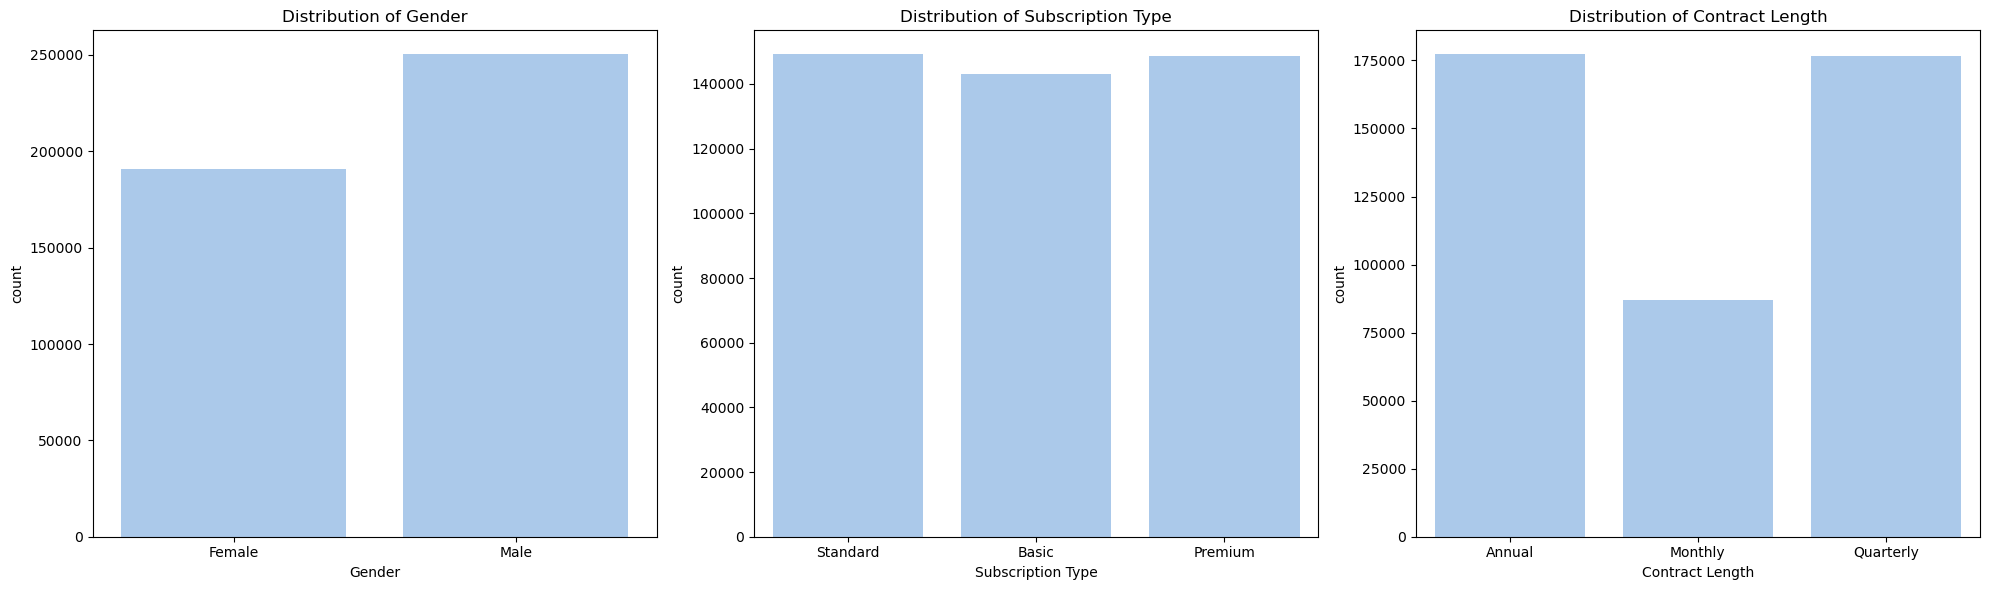

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(20, 6))
axes_list = axes.flatten()

for feature, ax in zip(categorical_features, axes_list):
    sns.countplot(data=df, x=feature, ax=ax)
    ax.set_title(f"Distribution of {feature}")

plt.tight_layout()
plt.show()

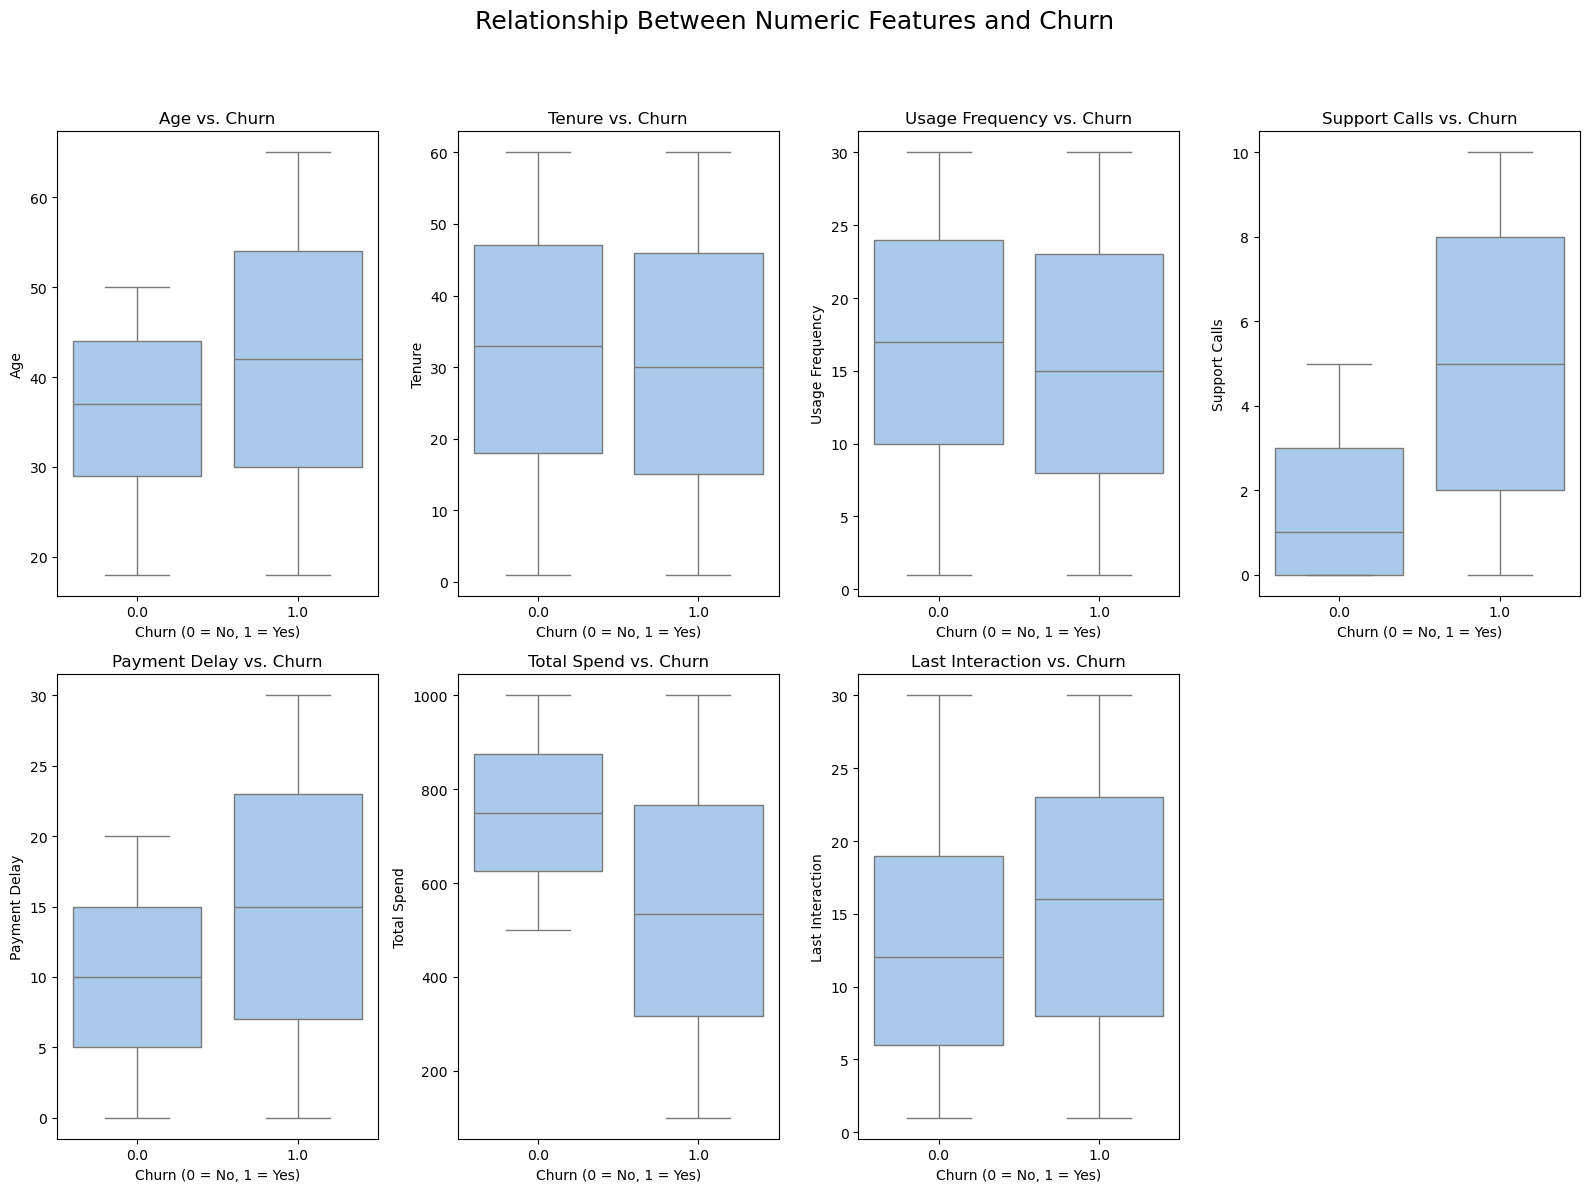

In [ ]:
plt.figure(figsize=(16, 12))
plt.suptitle("Relationship Between Numeric Features and Churn", fontsize=18, y=1.02)

for i, col in enumerate(numerical_features):
    plt.subplot(2, 4, i + 1)
    sns.boxplot(data=df, x="Churn", y=col)

    plt.title(f"{col} vs. Churn")
    plt.xlabel("Churn (0 = No, 1 = Yes)")
    plt.ylabel(col)

plt.tight_layout(rect=(0, 0.03, 1, 0.98))
plt.show()

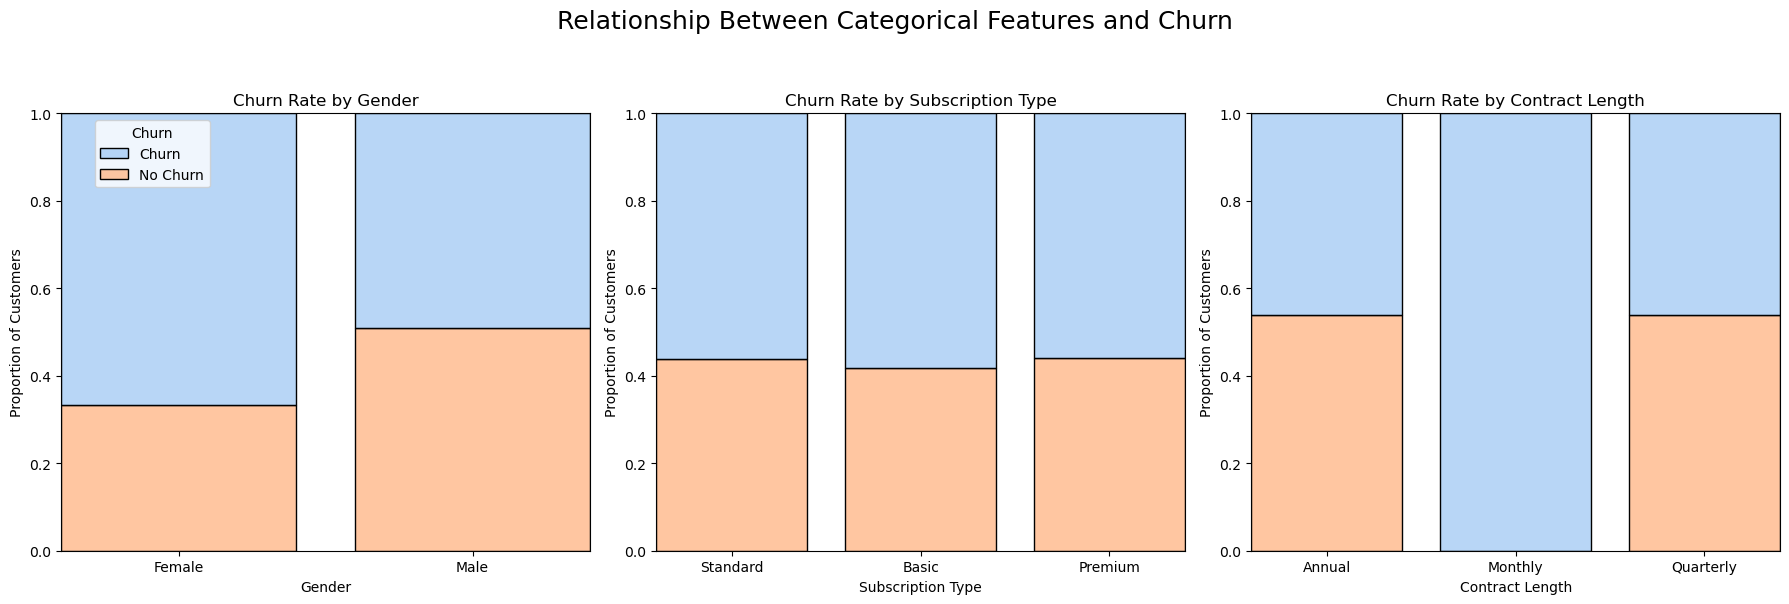

In [ ]:
plt.figure(figsize=(18, 6))
plt.suptitle("Relationship Between Categorical Features and Churn", fontsize=18, y=1.03)

df_plot = df.copy()
df_plot["Churn"] = df_plot["Churn"].map({0.0: "No Churn", 1.0: "Churn"})

for i, col in enumerate(categorical_features):
    plt.subplot(1, 3, i + 1)

    sns.histplot(
        data=df_plot,
        x=col,
        hue="Churn",  # Color-code the bars by 'Churn' status
        multiple="fill",  # Stack bars and normalize to 100% (fill)
        stat="proportion",  # Show proportions (not raw counts)
        discrete=True,  # Treat the x-axis as discrete categories
        shrink=0.8,  # Add a small gap between bars
    )

    plt.title(f"Churn Rate by {col}")
    plt.xlabel(col)
    plt.ylabel("Proportion of Customers")

    if i == 0:
        sns.move_legend(plt.gca(), "upper left", bbox_to_anchor=(0.05, 1))
    else:
        plt.gca().get_legend().remove()

plt.tight_layout(rect=(0, 0.03, 1, 0.98))
plt.show()

In [ ]:
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder

ordinal_encoder = OrdinalEncoder()
label_encoder = LabelEncoder()

In [ ]:
df["Subscription Type"] = ordinal_encoder.fit_transform(
    df["Subscription Type"].values.reshape(-1, 1)
)
df["Contract Length"] = ordinal_encoder.fit_transform(
    df["Contract Length"].values.reshape(-1, 1)
)
df["Gender"] = label_encoder.fit_transform(df["Gender"].values.reshape(-1, 1))
df.head()

c:\Users\HELLO\anaconda3\envs\myenv\Lib\site-packages\sklearn\preprocessing\_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,30.0,0,39.0,14.0,5.0,18.0,2.0,0.0,932.0,17.0,1.0
1,65.0,0,49.0,1.0,10.0,8.0,0.0,1.0,557.0,6.0,1.0
2,55.0,0,14.0,4.0,6.0,18.0,0.0,2.0,185.0,3.0,1.0
3,58.0,1,38.0,21.0,7.0,7.0,2.0,1.0,396.0,29.0,1.0
4,23.0,1,32.0,20.0,5.0,8.0,0.0,1.0,617.0,20.0,1.0


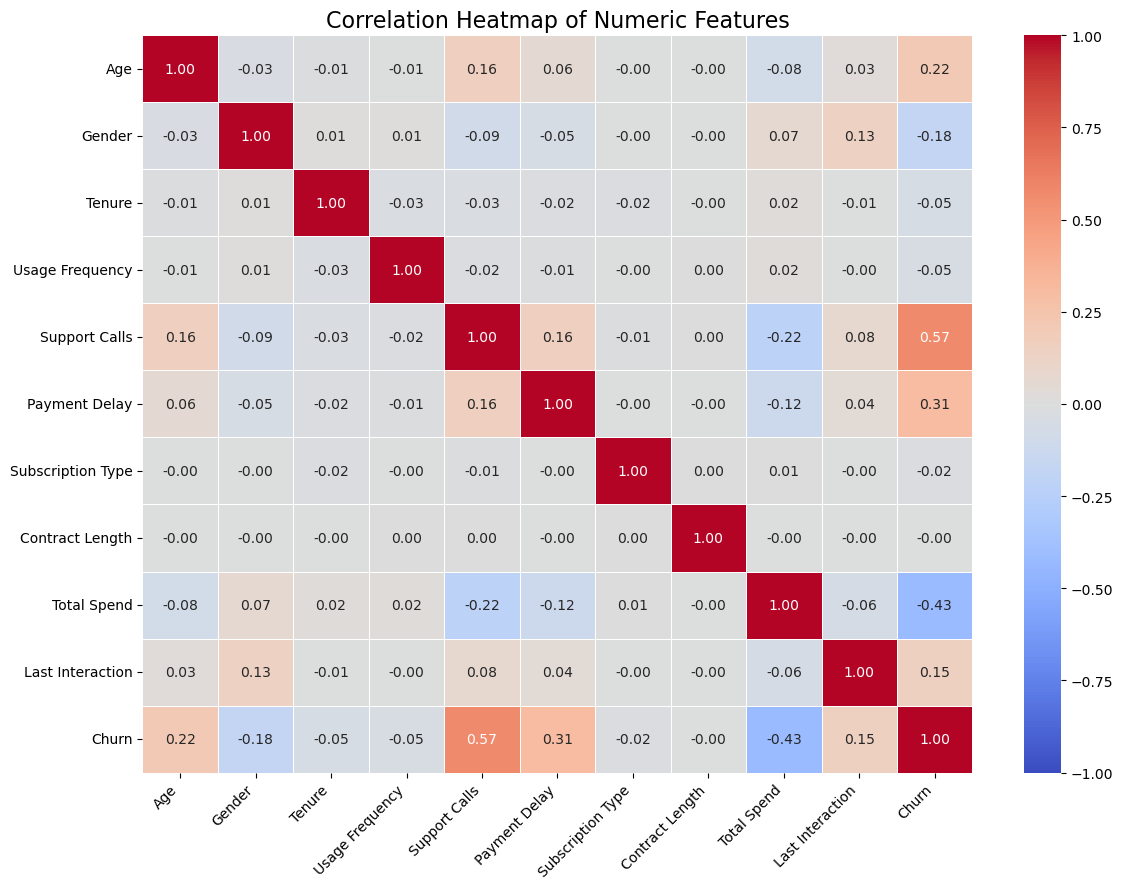

In [ ]:
numeric_df = df.select_dtypes(include=["float64", "int64"])
corr_matrix = numeric_df.corr()

plt.figure(figsize=(12, 9))
sns.heatmap(
    corr_matrix,
    annot=True,  # Display the correlation values on the heatmap
    fmt=".2f",  # Format the values to two decimal places
    cmap="coolwarm",  # Use a diverging colormap (blue=negative, red=positive)
    linewidths=0.5,  # Add fine lines between cells
    vmin=-1,  # Set the min of the colormap to -1
    vmax=1,  # Set the max of the colormap to +1
)

plt.title("Correlation Heatmap of Numeric Features", fontsize=16)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()